In [1]:
# env: music-umap as umpa needed numpy < 2
import pandas as pd
import umap
import matplotlib.pyplot as plt

/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
model_df = pd.read_csv('../data/processed/lastfm_music_clusters_final.csv')

In [4]:
model_df.head()

,artist,track,timestamp,year_file,artist_clean,track_clean,parentheses,tags,tags_clean,tags_normalized,tags_filtered,tags_str,cluster,cluster_name
0,Oasis,Don't Look Back in Anger,1199052426,2007,oasis,dont look back in anger,[],['britpop' 'rock' 'british' 'alternative' 'ind...,['indie' 'rock' 'british' '90s' 'alternative r...,"['indie', 'rock', 'british', '90s', 'alternati...","['indie', 'alternative', 'britpop']",indie alternative britpop,1,classic rock / blues / psychedelic
1,Oasis,Wonderwall,1199052167,2007,oasis,wonderwall,[],['britpop' 'rock' 'british' 'alternative' 'ind...,['indie' 'rock' 'british' '90s' 'alternative r...,"['indie', 'rock', 'british', '90s', 'alternati...","['indie', 'alternative', 'britpop']",indie alternative britpop,1,classic rock / blues / psychedelic
2,Incubus,Aqueous Transmission,1199051161,2007,incubus,aqueous transmission,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","['indie', 'funk metal', 'alternative', 'groovy...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz
3,Incubus,Under My Umbrella12DSGMS192,1199050947,2007,incubus,under my umbrella,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","['indie', 'funk metal', 'alternative', 'groovy...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz
4,Incubus,Are You In11DSGMS192,1199050681,2007,incubus,are you in,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","['indie', 'funk metal', 'alternative', 'groovy...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz


In [5]:
import ast

model_df["tags_filtered"] = model_df["tags_filtered"].apply(ast.literal_eval)

In [6]:
#TFIDFVectorizer breaks tags with spaces, so we need to join them with underscores

def join_tags(tags):
    return " ".join([t.replace(" ", "_") for t in tags])

model_df["tags_str"] = model_df["tags_filtered"].apply(join_tags)

In [7]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(model_df["tags_str"])

In [8]:
reducer = umap.UMAP(
    n_neighbors=30,      # lokalna struktura
    min_dist=0.05,        # większe skupienie
    metric="cosine",#  KLUCZOWE dla TF-IDF
    densmap=True,
    random_state=42
)
X_umap = reducer.fit_transform(X)

/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too sm

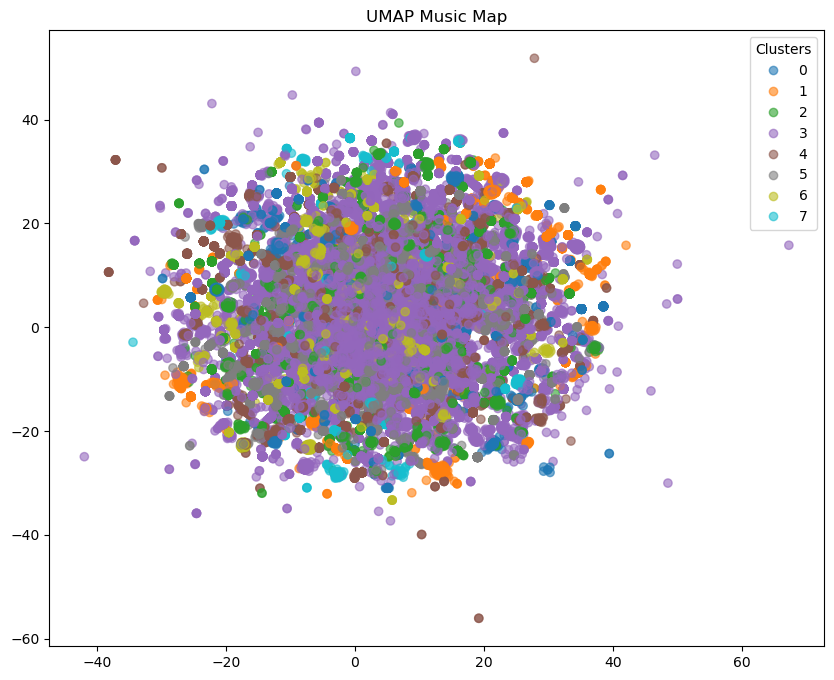

In [9]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=model_df["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title("UMAP Music Map")
plt.show()

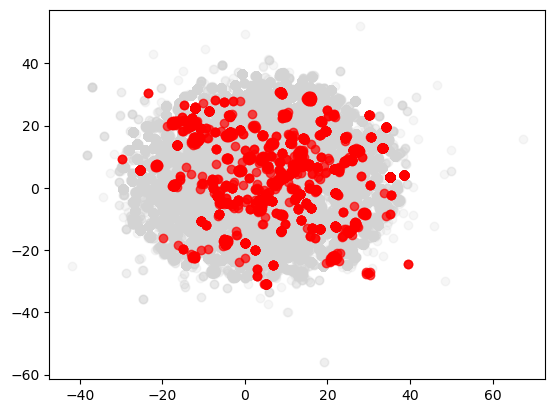

In [10]:
mask = model_df["cluster"] == 0

plt.scatter(X_umap[:,0], X_umap[:,1], color="lightgray", alpha=0.2)
plt.scatter(X_umap[mask,0], X_umap[mask,1], color="red", alpha=0.7)
plt.show()

In [13]:
from sklearn.manifold import TSNE

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    metric="cosine",
    random_state=42
).fit_transform(X.toarray())

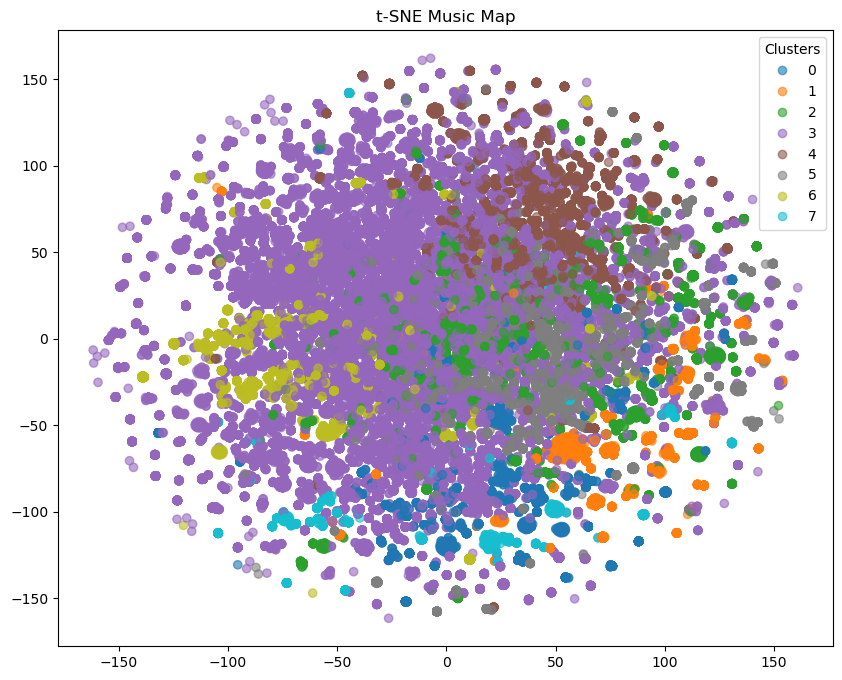

In [15]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=model_df["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title("t-SNE Music Map")
plt.show()

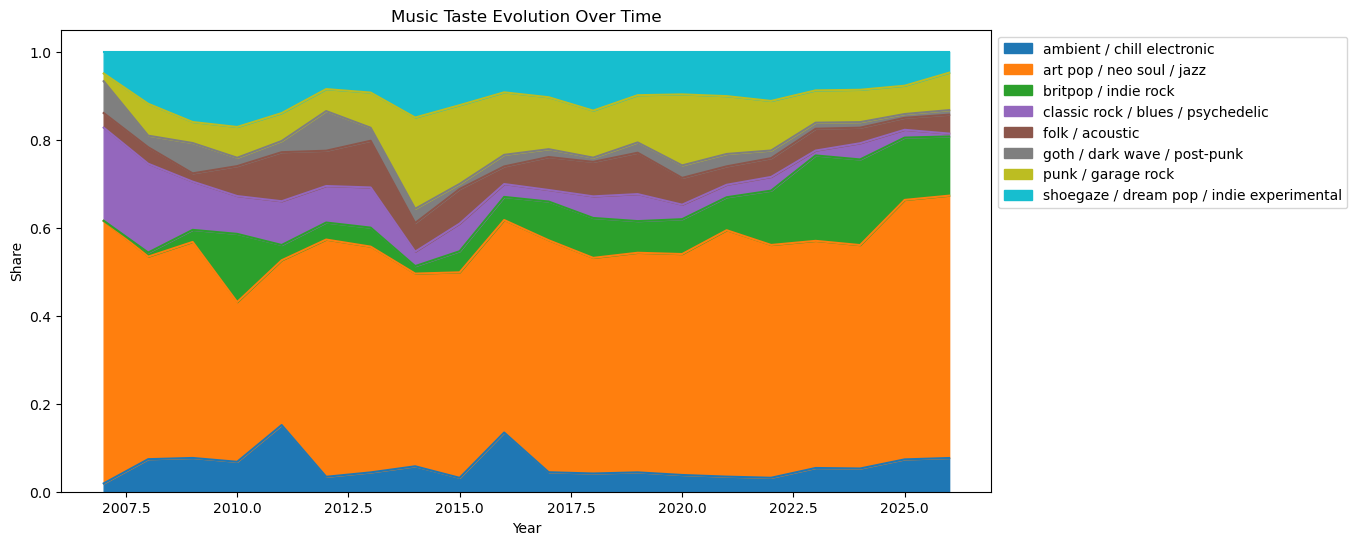

In [11]:
# Evolution of music taste over time

df = (
    model_df.groupby(["year_file", "cluster_name"])
    .size()
    .unstack(fill_value=0)
)

df_pct = df.div(df.sum(axis=1), axis=0)

df_pct.plot(kind="area", figsize=(12, 6), colormap="tab10")
plt.title("Music Taste Evolution Over Time")
plt.ylabel("Share")
plt.xlabel("Year")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

In [35]:
model_df.head()

,artist,track,timestamp,year_file,artist_clean,track_clean,parentheses,tags,tags_clean,tags_normalized,tags_filtered,tags_str,cluster,cluster_name,mood_cluster
0,Oasis,Don't Look Back in Anger,1199052426,2007,oasis,dont look back in anger,[],['britpop' 'rock' 'british' 'alternative' 'ind...,['indie' 'rock' 'british' '90s' 'alternative r...,"['indie', 'rock', 'british', '90s', 'alternati...","[indie, alternative, britpop]",indie alternative britpop,1,classic rock / blues / psychedelic,energetic
1,Oasis,Wonderwall,1199052167,2007,oasis,wonderwall,[],['britpop' 'rock' 'british' 'alternative' 'ind...,['indie' 'rock' 'british' '90s' 'alternative r...,"['indie', 'rock', 'british', '90s', 'alternati...","[indie, alternative, britpop]",indie alternative britpop,1,classic rock / blues / psychedelic,energetic
2,Incubus,Aqueous Transmission,1199051161,2007,incubus,aqueous transmission,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","[indie, funk metal, alternative, groovy, jecks...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz,smooth
3,Incubus,Under My Umbrella12DSGMS192,1199050947,2007,incubus,under my umbrella,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","[indie, funk metal, alternative, groovy, jecks...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz,smooth
4,Incubus,Are You In11DSGMS192,1199050681,2007,incubus,are you in,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","[indie, funk metal, alternative, groovy, jecks...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz,smooth


In [12]:
# Dominant mood per year

mood_map = {
    "ambient / chill electronic": "calm",
    "art pop / neo soul / jazz": "smooth",
    "britpop / indie rock": "nostalgic",
    "classic rock / blues / psychedelic": "energetic",
    "folk / acoustic": "soft",
    "goth / dark wave / post-punk": "dark",
    "punk / garage rock": "aggressive",
    "shoegaze / dream pop / indie experimental": "dreamy"
}

model_df["mood_cluster"] = model_df["cluster_name"].map(mood_map)

In [13]:
mood_counts = (
    model_df.groupby(["year_file", "mood_cluster"])
    .size()
    .unstack(fill_value=0)
)

dominant_mood = mood_counts.idxmax(axis=1)
# top2 = mood_counts.apply(lambda x: x.nlargest(2).index.tolist(), axis=1)

In [14]:
from scipy.stats import entropy
import numpy as np

mood_entropy = mood_counts.apply(lambda x: entropy(x), axis=1)

max_entropy = np.log(len(mood_counts.columns))
mood_entropy_norm = mood_entropy / max_entropy

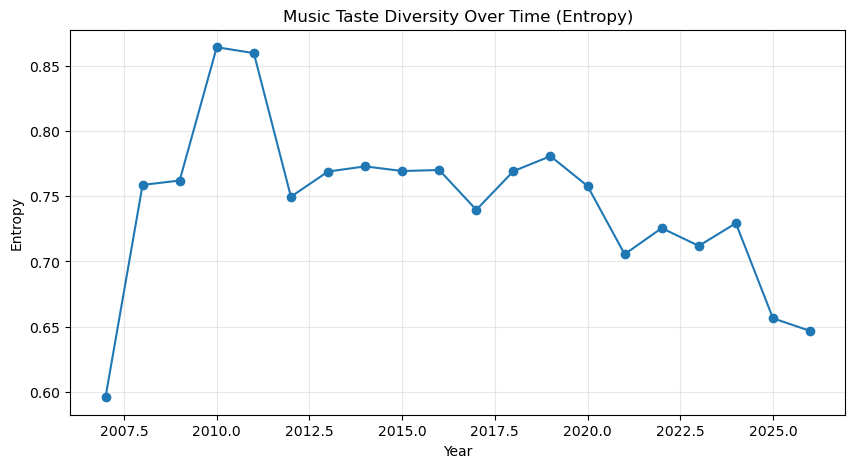

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    mood_entropy_norm.index,   # lata
    mood_entropy_norm.values,
    marker="o"
)

plt.title("Music Taste Diversity Over Time (Entropy)")
plt.xlabel("Year")
plt.ylabel("Entropy")

plt.grid(alpha=0.3)
plt.show()

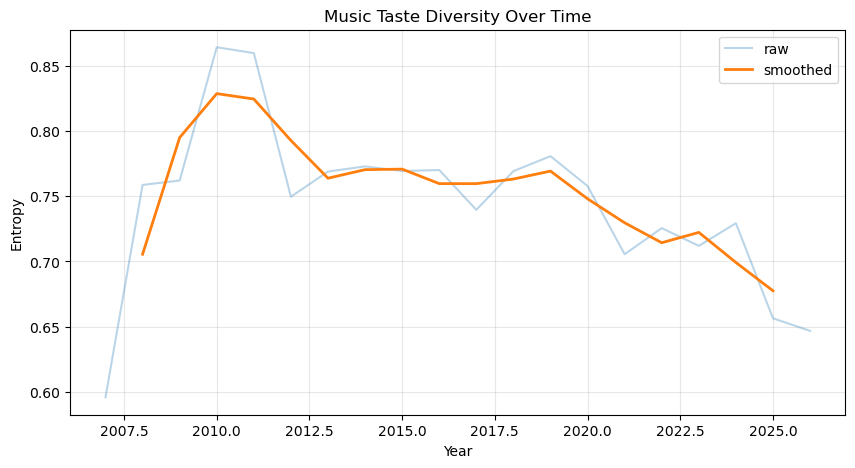

In [16]:
mood_entropy_smooth = mood_entropy_norm.rolling(3, center=True).mean()

plt.figure(figsize=(10, 5))

plt.plot(mood_entropy_norm.index, mood_entropy_norm.values, alpha=0.3, label="raw")
plt.plot(mood_entropy_norm.index, mood_entropy_smooth, linewidth=2, label="smoothed")

plt.legend()
plt.title("Music Taste Diversity Over Time")
plt.xlabel("Year")
plt.ylabel("Entropy")

plt.grid(alpha=0.3)
plt.show()

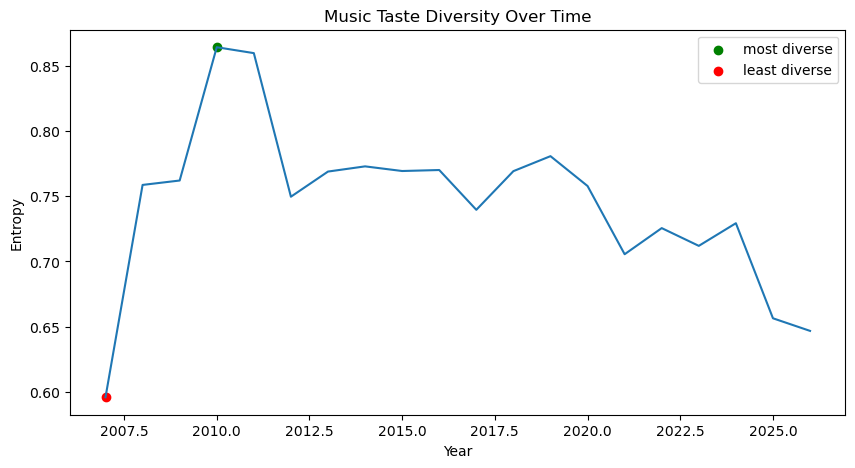

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(mood_entropy_norm.index, mood_entropy_norm.values)

max_year = mood_entropy_norm.idxmax()
min_year = mood_entropy_norm.idxmin()

plt.scatter(max_year, mood_entropy_norm.max(), color="green", label="most diverse")
plt.scatter(min_year, mood_entropy_norm.min(), color="red", label="least diverse")

plt.legend()
plt.title("Music Taste Diversity Over Time")
plt.xlabel("Year")
plt.ylabel("Entropy")

plt.show()

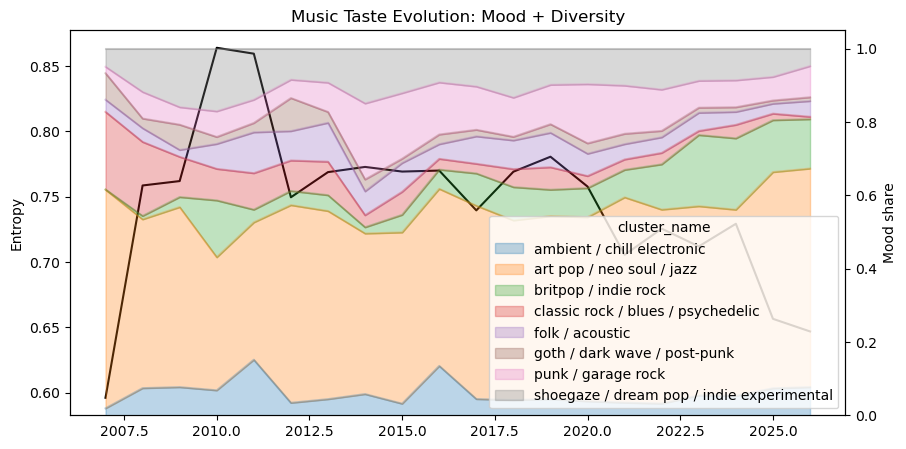

In [18]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(mood_entropy_norm.index, mood_entropy_norm.values, color="black", label="Entropy")
ax1.set_ylabel("Entropy")

ax2 = ax1.twinx()
df_pct.plot.area(ax=ax2, alpha=0.3)
ax2.set_ylabel("Mood share")

plt.title("Music Taste Evolution: Mood + Diversity")
plt.show()

In [ ]:
# 2010 → peak exploration
# 2015 → stabilization
# 2023+ → narrowing
# mam stabilny core gust (smooth), ale zmieniają się dodatki

In [63]:
# Save current dfs

model_df.to_csv(
    "../data/processed/final/music_taste_clusters_final.csv",
    index=False
)

import pickle

#model_df.to_pickle("../data/processed/final/music_taste_clusters_final.pkl")

with open(
    "../data/processed/final/music_taste_clusters_final.pkl",
    "wb"
) as f:
    pickle.dump(model_df, f)

In [ ]:
# how to load pickle, if needed:
with open(
    "../data/processed/music_taste_clusters_final.pkl",
    "rb"
) as f:
    model_df = pickle.load(f)

In [24]:
import pickle

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

In [25]:
# analysis of number of scrobbles per year, as entropy drastically dropped after 2024
#model_df.groupby("year_file").size().plot(kind="bar")
#plt.title("Number of Scrobbles per Year")
model_df.groupby("year_file").size()

year_file
2007    1536
2008    2055
2009    1277
2010    1000
2011    1498
2012    2120
2013    2639
2014    1765
2015    3359
2016    4779
2017    6276
2018    5193
2019    5476
2020    6096
2021    5539
2022    5328
2023    4781
2024    5457
2025    5579
2026    1070
dtype: int64

<Axes: xlabel='year_file'>

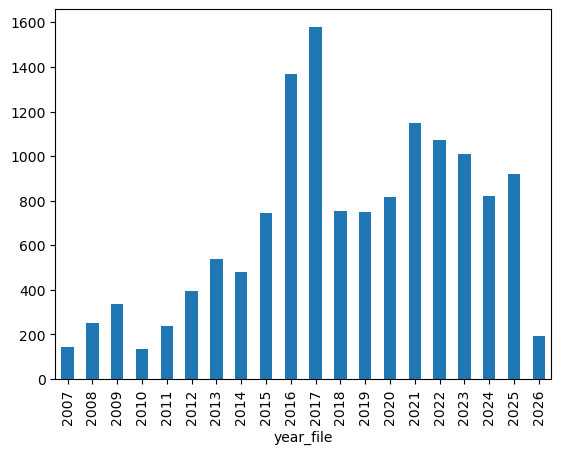

In [26]:
# How many new artists I discovered per year?

first_seen = (
    model_df
    .groupby("artist_clean")["year_file"]
    .min()
)

new_artists_per_year = (
    first_seen
    .value_counts()
    .sort_index()
)

new_artists_per_year.plot(kind="bar")

/var/folders/gp/nj314n8s4h90zghjg44d68xr0000gn/T/ipykernel_21119/2903956505.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(top20_share)


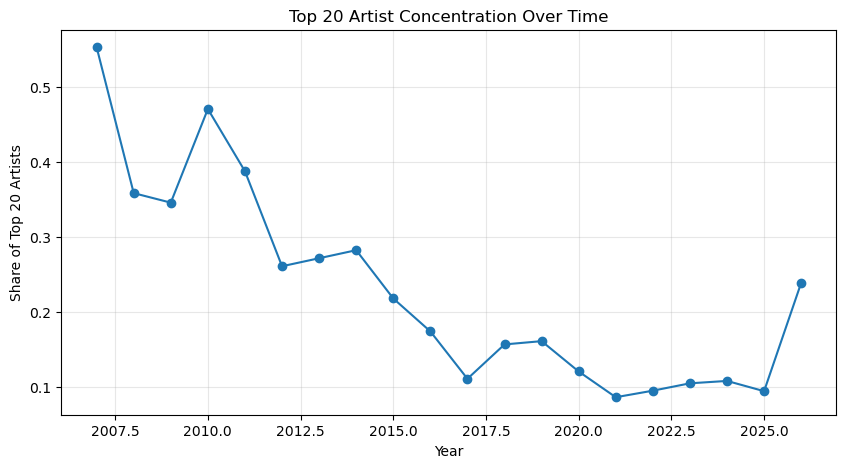

In [27]:
# How many artists came back? Top 20 artists each year?

def top20_share(group):
    counts = group["artist_clean"].value_counts()
    return counts.head(20).sum() / counts.sum()

artist_concentration = (
    model_df
    .groupby("year_file")
    .apply(top20_share)
)

plt.figure(figsize=(10,5))

plt.plot(
    artist_concentration.index,
    artist_concentration.values,
    marker="o"
)

plt.title("Top 20 Artist Concentration Over Time")
plt.xlabel("Year")
plt.ylabel("Share of Top 20 Artists")

plt.grid(alpha=0.3)
plt.show()

In [28]:
artist_concentration

year_file
2007    0.553385
2008    0.358812
2009    0.346124
2010    0.471000
2011    0.387989
2012    0.261321
2013    0.272003
2014    0.282720
2015    0.218350
2016    0.174423
2017    0.111235
2018    0.157063
2019    0.161432
2020    0.120968
2021    0.086658
2022    0.095381
2023    0.105197
2024    0.108381
2025    0.094716
2026    0.239171
dtype: float64

In [29]:
# Cluster transitions

df_pct.iloc[-1] - df_pct.iloc[0]

cluster_name
ambient / chill electronic                   0.057755
art pop / neo soul / jazz                   -0.000092
britpop / indie rock                         0.133928
classic rock / blues / psychedelic          -0.205046
folk / acoustic                              0.009788
goth / dark wave / post-punk                -0.061985
punk / garage rock                           0.067469
shoegaze / dream pop / indie experimental   -0.001816
dtype: float64

In [32]:
for cluster in model_df["cluster_name"].unique():
    print("\n")
    print(cluster)

    print(
        model_df[
            model_df["cluster_name"] == cluster
        ]["artist_clean"]
        .value_counts()
        .head(10)
    )



classic rock / blues / psychedelic
artist_clean
radiohead         197
placebo           165
myslovitz         156
suede             143
blur              126
coldplay          117
snow patrol       112
arctic monkeys    111
muse              111
oasis             103
Name: count, dtype: int64


art pop / neo soul / jazz
artist_clean
red hot chili peppers    207
david bowie              205
green day                166
the rolling stones       149
tlove                    148
the beatles              147
deftones                 145
incubus                  117
tori amos                115
james blake              114
Name: count, dtype: int64


goth / dark wave / post-punk
artist_clean
foo fighters             166
the smashing pumpkins    154
pearl jam                110
garbage                  110
nirvana                   77
hey                       61
the afghan whigs          57
alice in chains           54
pixies                    50
soundgarden               47
Name: count, 

In [33]:
top_50_all_time = model_df["artist_clean"].value_counts().head(50)

In [34]:
top_50_all_time

artist_clean
the cure                   215
depeche mode               213
red hot chili peppers      207
david bowie                205
radiohead                  197
the national               181
u2                         176
foo fighters               166
green day                  166
placebo                    165
pj harvey                  160
nick cave the bad seeds    158
myslovitz                  156
the smashing pumpkins      154
cat power                  149
the rolling stones         149
tlove                      148
the beatles                147
deftones                   145
bruce springsteen          145
lana del rey               144
suede                      143
bob dylan                  134
arcade fire                134
blur                       126
the smiths                 118
coldplay                   117
incubus                    117
sufjan stevens             115
tori amos                  115
james blake                114
interpol                  

In [36]:
cluster_names_v2 = {
    0: "Americana / indie folk",
    1: "British alternative rock",
    2: "Ambient / trip-hop / downtempo",
    3: "Alternative rock mainstream",
    4: "Neoclassical / soundtrack",
    5: "Art indie / dream pop",
    6: "Soul / R&B / funk",
    7: "Post-punk / goth / new wave"
}

model_df["cluster_name_v2"] = model_df["cluster"].map(cluster_names_v2)

In [37]:
for cluster in model_df["cluster_name_v2"].unique():
    print("\n")
    print(cluster)

    print(
        model_df[
            model_df["cluster_name_v2"] == cluster
        ]["artist_clean"]
        .value_counts()
        .head(10)
    )



British alternative rock
artist_clean
radiohead         197
placebo           165
myslovitz         156
suede             143
blur              126
coldplay          117
snow patrol       112
arctic monkeys    111
muse              111
oasis             103
Name: count, dtype: int64


Alternative rock mainstream
artist_clean
red hot chili peppers    207
david bowie              205
green day                166
the rolling stones       149
tlove                    148
the beatles              147
deftones                 145
incubus                  117
tori amos                115
james blake              114
Name: count, dtype: int64


Post-punk / goth / new wave
artist_clean
foo fighters             166
the smashing pumpkins    154
pearl jam                110
garbage                  110
nirvana                   77
hey                       61
the afghan whigs          57
alice in chains           54
pixies                    50
soundgarden               47
Name: count, dtype: in

In [ ]:
cluster_names_v3 = {
    0: "Alternative & Britrock",
    1: "Rock Canon & Alternative Classics",
    2: "Grunge & 90s Alternative",
    3: "Dark Alternative & Post-Punk",
    4: "Ambient & Trip-Hop Electronic",
    5: "Art Rock & Indie Experimental",
    6: "Americana & Singer-Songwriter",
    7: "Dream Pop & Modern Indie"
}

model_df["cluster_name_v3"] = model_df["cluster"].map(cluster_names_v3)

In [41]:
for cluster in model_df["cluster_name_v3"].unique():
    print("\n")
    print(cluster)

    print(
        model_df[
            model_df["cluster_name_v3"] == cluster
        ]["artist_clean"]
        .value_counts()
        .head(10)
    )



Rock Canon & Alternative Classics
artist_clean
radiohead         197
placebo           165
myslovitz         156
suede             143
blur              126
coldplay          117
snow patrol       112
arctic monkeys    111
muse              111
oasis             103
Name: count, dtype: int64


Dark Alternative & Post-Punk
artist_clean
red hot chili peppers    207
david bowie              205
green day                166
the rolling stones       149
tlove                    148
the beatles              147
deftones                 145
incubus                  117
tori amos                115
james blake              114
Name: count, dtype: int64


Dream Pop & Modern Indie
artist_clean
foo fighters             166
the smashing pumpkins    154
pearl jam                110
garbage                  110
nirvana                   77
hey                       61
the afghan whigs          57
alice in chains           54
pixies                    50
soundgarden               47
Name: count, dt

In [48]:
model_df["cluster_name_v3"].value_counts()

cluster_name_v3
Dark Alternative & Post-Punk         37296
Ambient & Trip-Hop Electronic         7763
Grunge & 90s Alternative              7446
Art Rock & Indie Experimental         6797
Alternative & Britrock                4257
Americana & Singer-Songwriter         3976
Rock Canon & Alternative Classics     3581
Dream Pop & Modern Indie              1707
Name: count, dtype: int64

In [49]:
model_df.groupby("cluster_name_v3")["artist_clean"].nunique()

cluster_name_v3
Alternative & Britrock                433
Ambient & Trip-Hop Electronic         953
Americana & Singer-Songwriter         439
Art Rock & Indie Experimental         830
Dark Alternative & Post-Punk         9874
Dream Pop & Modern Indie              126
Grunge & 90s Alternative              884
Rock Canon & Alternative Classics     171
Name: artist_clean, dtype: int64

In [50]:
model_df.groupby("cluster_name_v3").size()

cluster_name_v3
Alternative & Britrock                4257
Ambient & Trip-Hop Electronic         7763
Americana & Singer-Songwriter         3976
Art Rock & Indie Experimental         6797
Dark Alternative & Post-Punk         37296
Dream Pop & Modern Indie              1707
Grunge & 90s Alternative              7446
Rock Canon & Alternative Classics     3581
dtype: int64

In [51]:
(
    model_df["cluster_name_v3"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

cluster_name_v3
Dark Alternative & Post-Punk         51.2
Ambient & Trip-Hop Electronic        10.7
Grunge & 90s Alternative             10.2
Art Rock & Indie Experimental         9.3
Alternative & Britrock                5.8
Americana & Singer-Songwriter         5.5
Rock Canon & Alternative Classics     4.9
Dream Pop & Modern Indie              2.3
Name: proportion, dtype: float64

In [52]:
model_df.groupby("cluster_name_v3")["tags_filtered"].count()

cluster_name_v3
Alternative & Britrock                4257
Ambient & Trip-Hop Electronic         7763
Americana & Singer-Songwriter         3976
Art Rock & Indie Experimental         6797
Dark Alternative & Post-Punk         37296
Dream Pop & Modern Indie              1707
Grunge & 90s Alternative              7446
Rock Canon & Alternative Classics     3581
Name: tags_filtered, dtype: int64

In [53]:
macro_map = {
    "Dark Alternative & Post-Punk": "Alternative Core",

    "Rock Canon & Alternative Classics": "Rock",
    "Alternative & Britrock": "Rock",
    "Grunge & 90s Alternative": "Rock",

    "Ambient & Trip-Hop Electronic": "Electronic",
    "Art Rock & Indie Experimental": "Electronic",
    "Dream Pop & Modern Indie": "Electronic",

    "Americana & Singer-Songwriter": "Songwriter"
}

model_df["macro_cluster_v2"] = model_df["cluster_name_v3"].map(macro_map)

In [55]:
model_df["macro_cluster"].value_counts(normalize=True)

macro_cluster
Dark Alternative    0.614394
Electronic          0.199937
Rock                0.107631
Songwriter          0.054598
Dream Pop           0.023440
Name: proportion, dtype: float64

In [54]:
model_df["macro_cluster_v2"].value_counts(normalize=True)

macro_cluster_v2
Alternative Core    0.512146
Electronic          0.223377
Rock                0.209879
Songwriter          0.054598
Name: proportion, dtype: float64

In [56]:
macro_year = (
    model_df
    .groupby(["year_file", "macro_cluster_v2"])
    .size()
    .unstack(fill_value=0)
)

macro_pct = macro_year.div(
    macro_year.sum(axis=1),
    axis=0
)

macro_pct.head()

macro_cluster_v2,Alternative Core,Electronic,Rock,Songwriter
year_file,,,,
2007,0.596354,0.090495,0.294271,0.018880
2008,0.460341,0.108029,0.357664,0.073966
2009,0.490995,0.144088,0.288175,0.076742
2010,0.363000,0.244000,0.325000,0.068000
2011,0.374499,0.123498,0.350467,0.151535


In [57]:
macro_pct.tail()

macro_cluster_v2,Alternative Core,Electronic,Rock,Songwriter
year_file,,,,
2022,0.529092,0.253566,0.185623,0.031719
2023,0.516210,0.281322,0.148504,0.053964
2024,0.507788,0.280740,0.158695,0.052776
2025,0.589711,0.214555,0.122244,0.073490
2026,0.596262,0.229907,0.097196,0.076636


<Figure size 1200x600 with 0 Axes>

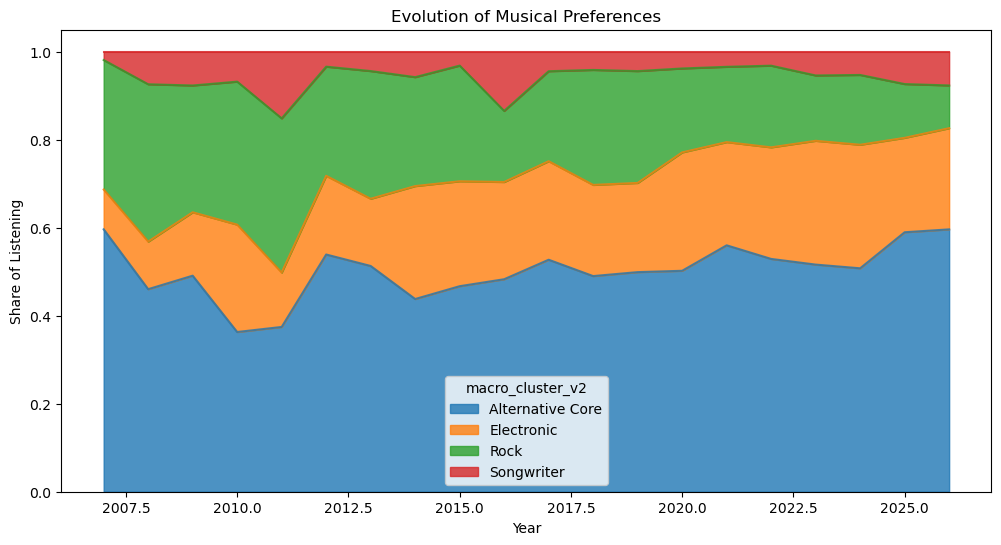

In [58]:
plt.figure(figsize=(12,6))

macro_pct.plot.area(
    figsize=(12,6),
    alpha=0.8
)

plt.title("Evolution of Musical Preferences")
plt.ylabel("Share of Listening")
plt.xlabel("Year")

plt.show()

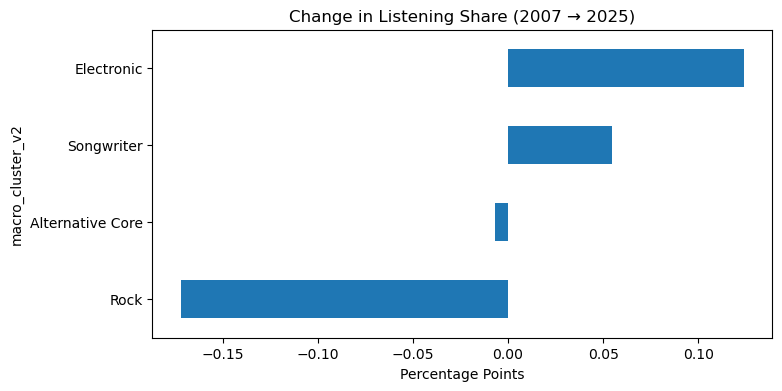

In [61]:
# Change in listening share over time
change = macro_pct.iloc[-2] - macro_pct.iloc[0]
# -2 żeby pominąć niepełny 2026

change.sort_values().plot.barh(
    figsize=(8, 4)
)

plt.title("Change in Listening Share (2007 → 2025)")
plt.xlabel("Percentage Points")
plt.show()

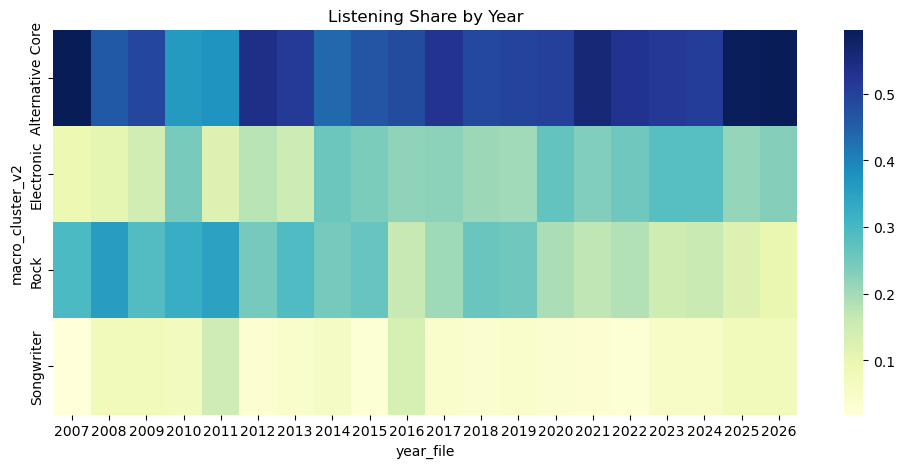

In [62]:
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.heatmap(
    macro_pct.T,
    cmap="YlGnBu"
)

plt.title("Listening Share by Year")
plt.show()

In [65]:
# Top artist by Era

def assign_era(year):
    if year <= 2011:
        return "2007-2011"
    elif year <= 2016:
        return "2012-2016"
    elif year <= 2021:
        return "2017-2021"
    else:
        return "2022-2026"

model_df["era"] = model_df["year_file"].apply(assign_era)

In [66]:
# Top 10 artists per era
top_artists_by_era = (
    model_df
    .groupby("era")["artist_clean"]
    .value_counts()
    .groupby(level=0)
    .head(10)
)

top_artists_by_era


era        artist_clean            
2007-2011  red hot chili peppers       129
           tlove                       122
           incubus                     106
           placebo                     105
           myslovitz                   102
           foo fighters                 96
           radiohead                    89
           cat power                    88
           green day                    88
           pidama porno                 88
2012-2016  kate bush                   102
           new order                    99
           depeche mode                 94
           u2                           89
           biffy clyro                  88
           beastie boys                 76
           radiohead                    68
           the smashing pumpkins        68
           the prodigy                  67
           the rolling stones           63
2017-2021  the cure                    111
           nick cave the bad seeds     104
           suede  

In [67]:
# Discovery rate

first_seen = (
    model_df
    .groupby("artist_clean")["year_file"]
    .min()
)

new_artists_per_year = (
    first_seen
    .value_counts()
    .sort_index()
)

artists_per_year = (
    model_df
    .groupby("year_file")["artist_clean"]
    .nunique()
)

discovery_rate = (
    new_artists_per_year
    / artists_per_year
)

discovery_rate

year_file
2007    1.000000
2008    0.745562
2009    0.775982
2010    0.632558
2011    0.625654
2012    0.643322
2013    0.654080
2014    0.640479
2015    0.670557
2016    0.676718
2017    0.601295
2018    0.445363
2019    0.419989
2020    0.385161
2021    0.453002
2022    0.429200
2023    0.501739
2024    0.383824
2025    0.423254
2026    0.353261
dtype: float64